In [1]:
import pandas as pd
import numpy as np 


In [2]:
df = pd.read_csv("../data/raw/ipums_acs/usa_00001.csv")
new_df = df[df["YEAR"]>= 2014]
new_df.head()


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEFIP,STRATA,GQ,PERNUM,PERWT,BPL,BPLD,CITIZEN,EDUC,EDUCD,OCC,INCTOT
50520719,2014,201401,1,7.0,52.0,2014000000011,1,240001,1,1,52.0,1,100,0.0,6.0,63.0,7210.0,45000.0
50520720,2014,201401,1,7.0,52.0,2014000000011,1,240001,1,2,35.0,1,100,0.0,0.0,2.0,0.0,0.0
50520721,2014,201401,1,7.0,52.0,2014000000011,1,240001,1,3,198.0,1,100,0.0,0.0,2.0,6200.0,0.0
50520722,2014,201401,1,7.0,52.0,2014000000011,1,240001,1,4,101.0,1,100,0.0,2.0,26.0,0.0,0.0
50520723,2014,201401,1,7.0,52.0,2014000000011,1,240001,1,5,95.0,1,100,0.0,2.0,26.0,0.0,9999999.0


In [3]:
#Filter out the post-2024 data and make chunks
input_raw = "../data/raw/ipums_acs/usa_00001.csv"
output_2014 = "../data/raw/ipums_acs/usa_2014_plus.csv"
first_chunk = True
for chunk in pd.read_csv(input_raw, chunksize=100000):
    filtered = chunk[chunk["YEAR"]>= 2014]

    if first_chunk:
            filtered.to_csv(output_2014, mode='w', index=False, header=True)
            first_chunk = False
    else:
        filtered.to_csv(output_2014, mode='a', index=False, header=False)
parqueth = "../data/raw/ipums_acs/usa_2014_plus.parquet"
par_output_2014 = pd.read_csv(output_2014)
par_output_2014.to_parquet(parqueth, engine='pyarrow', index=False)
print("Done")


Done


In [4]:
df = pd.read_parquet(parqueth, columns = ['YEAR', 'STATEFIP', 'BPL', 'CITIZEN',
      'EDUC', 'OCC', 'INCTOT', 'PERWT'])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35175962 entries, 0 to 35175961
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   YEAR      int64  
 1   STATEFIP  int64  
 2   BPL       int64  
 3   CITIZEN   int64  
 4   EDUC      int64  
 5   OCC       int64  
 6   INCTOT    int64  
 7   PERWT     float64
dtypes: float64(1), int64(7)
memory usage: 2.1 GB


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35175962 entries, 0 to 35175961
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   YEAR      int64  
 1   STATEFIP  int64  
 2   BPL       int64  
 3   CITIZEN   int64  
 4   EDUC      int64  
 5   OCC       int64  
 6   INCTOT    int64  
 7   PERWT     float64
dtypes: float64(1), int64(7)
memory usage: 2.1 GB


In [6]:
# 1. Handle missing codes
missing_codes = {
    'INCTOT': 9999999, 
    'OCC': 0, 
    'EDUC': 0, 
    'CITIZEN': 0
}
# Replace missing codes with NaN to avoid statistical skew
for col, code in missing_codes.items():
    df[col] = df[col].replace(code, np.nan)
    
# Drop rows where critical variables (Education or Occupation) are NaN
df_clean = df.dropna(subset=['EDUC', 'OCC']).copy()
print(f"Data shape after cleaning: {df_clean.shape}")

Data shape after cleaning: (20606293, 8)


In [7]:
df_clean['highly_educated'] = df_clean['EDUC'] >= 10
df_clean['low_skill_job'] = df_clean['OCC'] >= 3600

df_clean['is_brain_waste'] = df_clean['highly_educated'] & df_clean['low_skill_job']

print("Total Highly Educated in sample:", df_clean['highly_educated'].sum())
print("Total Brain Waste Cases in sample:", df_clean['is_brain_waste'].sum())

Total Highly Educated in sample: 7339648
Total Brain Waste Cases in sample: 1975044


In [8]:
df_clean['is_imigrant'] = df_clean['BPL'] >= 100

educated_only = df_clean[df_clean['highly_educated'] == True].copy()

agg_df = educated_only.groupby(['STATEFIP','is_imigrant']).apply(
    lambda x: pd.Series({
        'total_educated_pop': x['PERWT'].sum(),
        'brain_waste_pop': (x['is_brain_waste']* x['PERWT']).sum()
    }), include_groups=False
).reset_index()

# Calculate the actual percentage of brain waste
agg_df['brain_waste_pct'] = (agg_df['brain_waste_pop'] / agg_df['total_educated_pop']) * 100
print(agg_df.head(10))

   STATEFIP  is_imigrant  total_educated_pop  brain_waste_pop  brain_waste_pct
0         1        False           7873328.0        2254200.0        28.630841
1         1         True            577668.0         163979.0        28.386374
2         2        False           1277693.0         383088.0        29.982789
3         2         True            178081.0          74827.0        42.018520
4         4        False          11581500.0        3348463.0        28.912170
5         4         True           2187514.0         645835.0        29.523697
6         5        False           4299300.0        1239879.0        28.839090
7         5         True            333364.0          96342.0        28.899941
8         6        False          62090803.0       16486199.0        26.551757
9         6         True          28445379.0        7924749.0        27.859530


In [9]:
# IPUMS FIPS to US State Mapping
fips_to_state = {
    1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California',
    8: 'Colorado', 9: 'Connecticut', 10: 'Delaware', 11: 'District of Columbia',
    12: 'Florida', 13: 'Georgia', 15: 'Hawaii', 16: 'Idaho', 17: 'Illinois',
    18: 'Indiana', 19: 'Iowa', 20: 'Kansas', 21: 'Kentucky', 22: 'Louisiana',
    23: 'Maine', 24: 'Maryland', 25: 'Massachusetts', 26: 'Michigan',
    27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana',
    31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey',
    35: 'New Mexico', 36: 'New York', 37: 'North Carolina', 38: 'North Dakota',
    39: 'Ohio', 40: 'Oklahoma', 41: 'Oregon', 42: 'Pennsylvania', 44: 'Rhode Island',
    45: 'South Carolina', 46: 'South Dakota', 47: 'Tennessee', 48: 'Texas',
    49: 'Utah', 50: 'Vermont', 51: 'Virginia', 53: 'Washington', 54: 'West Virginia',
    55: 'Wisconsin', 56: 'Wyoming'
}

# Create a new column with the human-readable state name
agg_df['US_State'] = agg_df['STATEFIP'].map(fips_to_state)

# Reorder columns for readability
agg_df = agg_df[['STATEFIP', 'US_State', 'is_imigrant', 'total_educated_pop', 'brain_waste_pop', 'brain_waste_pct']]

print(agg_df.head())


   STATEFIP US_State  is_imigrant  total_educated_pop  brain_waste_pop  \
0         1  Alabama        False           7873328.0        2254200.0   
1         1  Alabama         True            577668.0         163979.0   
2         2   Alaska        False           1277693.0         383088.0   
3         2   Alaska         True            178081.0          74827.0   
4         4  Arizona        False          11581500.0        3348463.0   

   brain_waste_pct  
0        28.630841  
1        28.386374  
2        29.982789  
3        42.018520  
4        28.912170  


In [10]:
import os

# 1. Create a "processed" folder if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# 2. Save your aggregated calculations as both JSON and CSV
agg_df.to_json('../data/processed/brain_waste_by_region.json', orient='records')
agg_df.to_csv('../data/processed/brain_waste_by_region.csv', index=False)

print("✅ Data successfully saved! You no longer need to run the raw IPUMS data cells.")


✅ Data successfully saved! You no longer need to run the raw IPUMS data cells.


In [11]:
# 1. Map BPL codes to World Regions & Top Origins
def map_bpl_to_region(bpl):
    if bpl < 100:
        return "Native-born (USA)"
    elif bpl == 200:
        return "Mexico"
    elif bpl == 530:
        return "India"
    elif 500 <= bpl <= 510:
        return "China/East Asia"
    elif bpl == 515:
        return "Philippines"
    elif 500 <= bpl < 600:
        return "Other Asia"
    elif 400 <= bpl < 500:
        return "Europe"
    elif 200 <= bpl < 400:
        return "Central/South America & Caribbean"
    elif 600 <= bpl < 700:
        return "Africa"
    else:
        return "Other Immigrants"

# Apply the mapping to our educated subset
educated_only['Origin_Region'] = educated_only['BPL'].apply(map_bpl_to_region)

# 2. Run the Aggregation including the new Origin_Region
agg_region_df = educated_only.groupby(['STATEFIP', 'Origin_Region']).apply(
    lambda x: pd.Series({
        'total_educated_pop': x['PERWT'].sum(),
        'brain_waste_pop': (x['is_brain_waste'] * x['PERWT']).sum()
    }), include_groups=False
).reset_index()

# 3. Calculate percentages
agg_region_df['brain_waste_pct'] = (agg_region_df['brain_waste_pop'] / agg_region_df['total_educated_pop']) * 100

# 4. Map the US_State names (using the dictionary from earlier)
agg_region_df['US_State'] = agg_region_df['STATEFIP'].map(fips_to_state)

# Sort to see the largest populations first
print(agg_region_df.sort_values(by='total_educated_pop', ascending=False).head(15))


     STATEFIP      Origin_Region  total_educated_pop  brain_waste_pop  \
41          6  Native-born (USA)          62090803.0       16486199.0   
392        48  Native-born (USA)          45606410.0       12255378.0   
293        36  Native-born (USA)          39012657.0       10511402.0   
86         12  Native-born (USA)          31033893.0        9503731.0   
347        42  Native-born (USA)          25999889.0        7087664.0   
122        17  Native-born (USA)          25677946.0        7232232.0   
320        39  Native-born (USA)          21403134.0        5813787.0   
302        37  Native-born (USA)          20161100.0        5818582.0   
95         13  Native-born (USA)          18989576.0        5487306.0   
419        51  Native-born (USA)          18779705.0        4700666.0   
275        34  Native-born (USA)          18394449.0        5036953.0   
194        25  Native-born (USA)          17875028.0        4534534.0   
203        26  Native-born (USA)          17672098.

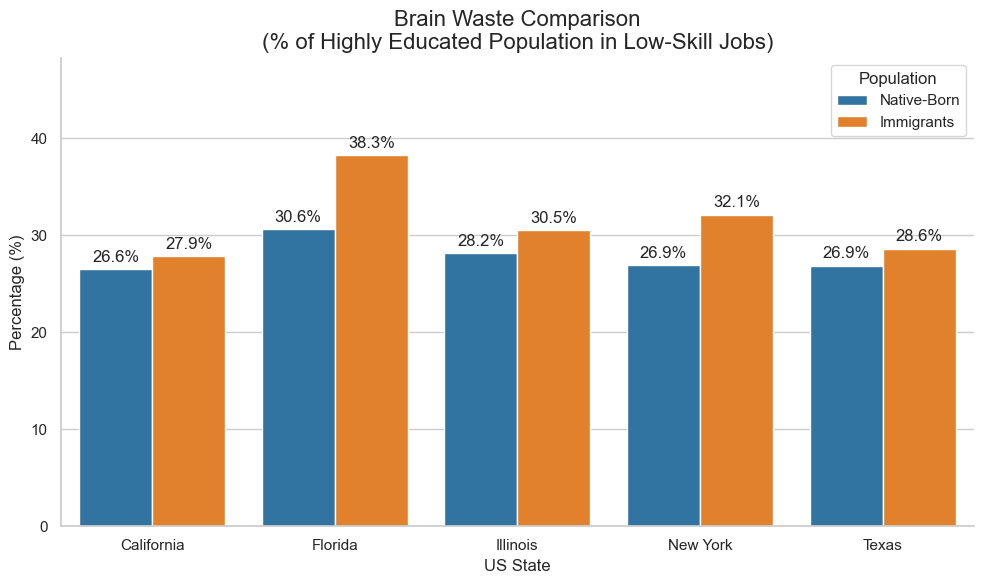

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Load the pre-calculated, lightweight dataset instantly
agg_df = pd.read_json('../data/processed/brain_waste_by_region.json')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16})

top_states = [6, 48, 36, 12, 17]
state_names = {6: 'California', 48: 'Texas', 36: 'New York', 12: 'Florida', 17: 'Illinois'}

plot_df = agg_df[agg_df['STATEFIP'].isin(top_states)].copy()
plot_df['State Name'] = plot_df['STATEFIP'].map(state_names)
plot_df['Population'] = plot_df['is_imigrant'].map({True: 'Immigrants', False: 'Native-Born'})

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_df, 
    x='State Name', 
    y='brain_waste_pct', 
    hue='Population',
    palette=['#1f77b4', '#ff7f0e'] # Blue and Orange
)
plt.title('Brain Waste Comparison\n(% of Highly Educated Population in Low-Skill Jobs)')
plt.ylabel('Percentage (%)')
plt.xlabel('US State')
# Add percentage labels on top of the bars for clarity
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)
# Expand Y-axis slightly so labels fit
plt.ylim(0, plot_df['brain_waste_pct'].max() + 10)
sns.despine()
plt.tight_layout()
plt.show()

In [13]:
# Load the CSV, stripping the spaces after commas
founders_df = pd.read_csv('../data/raw/founders/eu_tech_founders_stats.csv', skipinitialspace=True)

# Strip whitespace from column NAMES AND all string cell values
# (The CSV has trailing spaces in every cell, not just headers)
founders_df.columns = founders_df.columns.str.strip()
founders_df = founders_df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

# Filter out the "percent_increase" row so we are only comparing standard percentages (0-100)
percent_df = founders_df[founders_df['unit'] == 'percent'].copy()
print(f'Rows after filter: {len(percent_df)}')  # Should print 6

# Create a readable label combining the region and metric
percent_df['metric_clean'] = percent_df['metric'].str.replace('_', ' ').str.title()
percent_df['label'] = percent_df['country_or_region'] + " - " + percent_df['metric_clean']

# Sort for a clean horizontal cascade
percent_df = percent_df.sort_values(by='value', ascending=True)


Rows after filter: 7


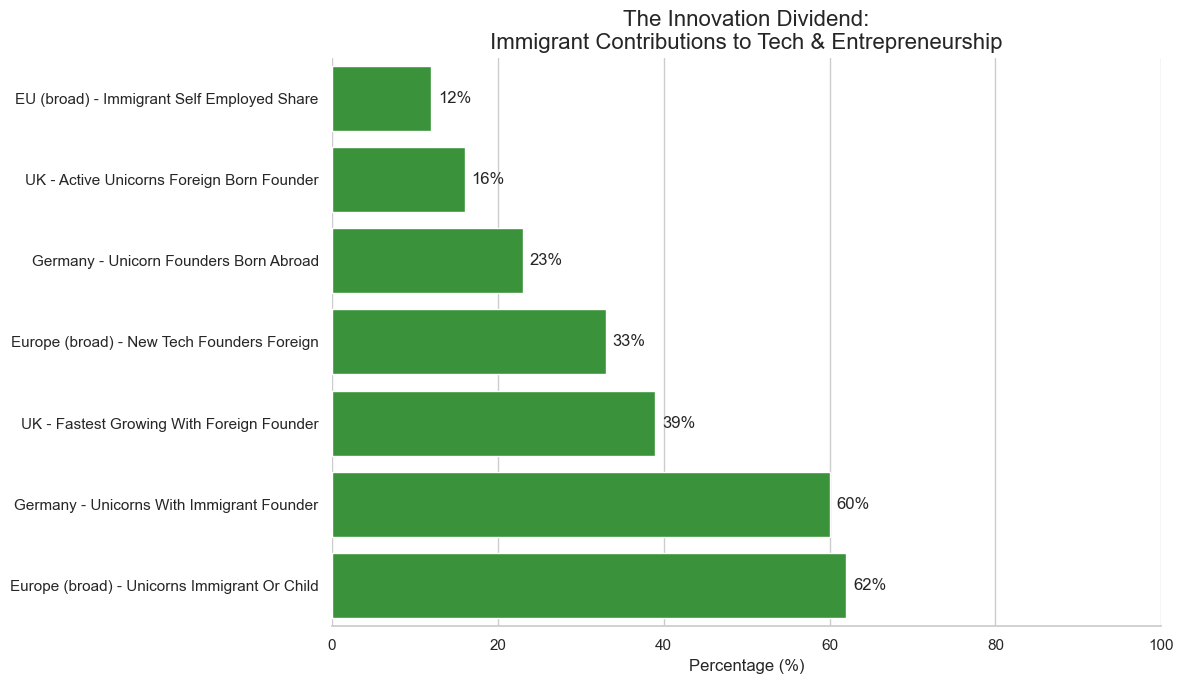

In [14]:
# Create the plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=percent_df,
    x='value',
    y='label',
    color='#2ca02c' # Green for "Innovation/Dividend"
)
plt.title('The Innovation Dividend:\nImmigrant Contributions to Tech & Entrepreneurship')
plt.xlabel('Percentage (%)')
plt.ylabel('')
plt.xlim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=5)
sns.despine(left=True)
plt.tight_layout()
plt.show()

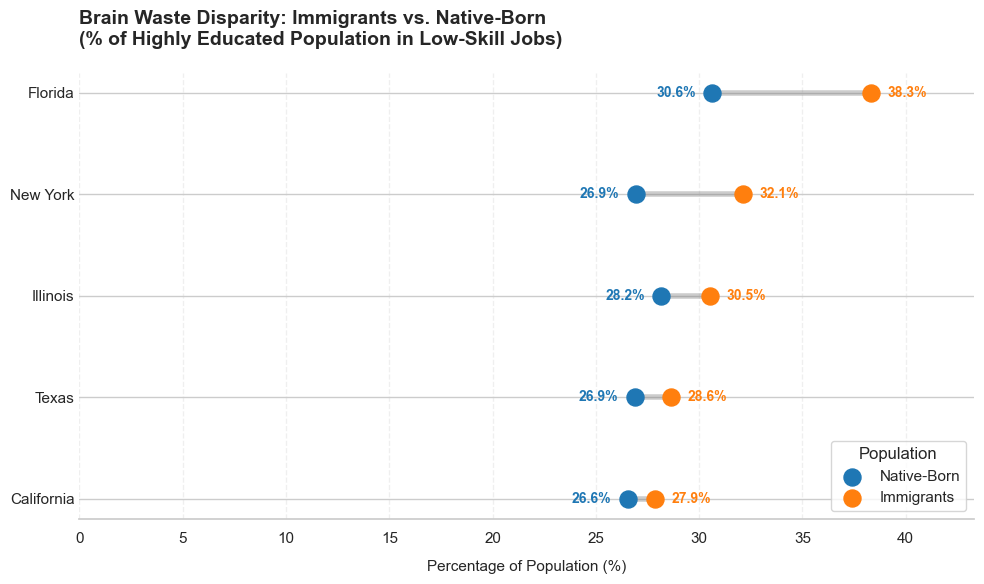

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data for Dumbbell Plot (Pivot so each row is a State)
plot_df = agg_df[agg_df['STATEFIP'].isin(top_states)].copy()
plot_df['State Name'] = plot_df['STATEFIP'].map(state_names)
plot_df['Population'] = plot_df['is_imigrant'].map({True: 'Immigrants', False: 'Native-Born'})

# Pivot to have Immigrants and Native-Born as separate columns
pivot_df = plot_df.pivot(index='State Name', columns='Population', values='brain_waste_pct').reset_index()

# Calculate the disparity gap and sort states by the gap for a clean cascade
pivot_df['Gap'] = pivot_df['Immigrants'] - pivot_df['Native-Born']
pivot_df = pivot_df.sort_values('Gap', ascending=True)

# 2. Plotting
plt.figure(figsize=(10, 6))

# Draw the connecting lines (the "dumbbell" bar)
plt.hlines(
    y=pivot_df['State Name'], 
    xmin=pivot_df['Native-Born'], 
    xmax=pivot_df['Immigrants'], 
    color='gray', 
    alpha=0.4, 
    linewidth=4,
    zorder=1
)

# Draw the Native-Born dots
plt.scatter(
    pivot_df['Native-Born'], 
    pivot_df['State Name'], 
    color='#1f77b4', 
    label='Native-Born', 
    s=150, 
    zorder=2
)

# Draw the Immigrants dots
plt.scatter(
    pivot_df['Immigrants'], 
    pivot_df['State Name'], 
    color='#ff7f0e', 
    label='Immigrants', 
    s=150, 
    zorder=2
)

# Add numeric text labels right next to the dots
for i, row in pivot_df.iterrows():
    # Native-born label (left of the blue dot)
    plt.text(
        row['Native-Born'] - 0.8, 
        row['State Name'], 
        f"{row['Native-Born']:.1f}%", 
        va='center', ha='right', color='#1f77b4', fontweight='bold', fontsize=10
    )
    # Immigrants label (right of the orange dot)
    plt.text(
        row['Immigrants'] + 0.8, 
        row['State Name'], 
        f"{row['Immigrants']:.1f}%", 
        va='center', ha='left', color='#ff7f0e', fontweight='bold', fontsize=10
    )

# 3. Aesthetics & Cleanup
plt.title('Brain Waste Disparity: Immigrants vs. Native-Born\n(% of Highly Educated Population in Low-Skill Jobs)', loc='left', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Population (%)', fontsize=11, labelpad=10)
plt.ylabel('')  # Remove 'State Name' as it's obvious
plt.xlim(0, pivot_df['Immigrants'].max() + 5) # Buffer on the right for labels

# Clean legend
plt.legend(loc='lower right', frameon=True, title='Population')

# Remove borders for a cleaner look
sns.despine(left=True, bottom=False)
ax = plt.gca()
ax.tick_params(axis='y', length=0) # Remove y-axis ticks
ax.grid(axis='x', linestyle='--', alpha=0.3) # Add light vertical grid lines for readability

plt.tight_layout()
plt.show()


/var/folders/85/ln0lfzpn3qz_qhy3jy21018w0000gn/T/ipykernel_53179/2304102518.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  region_stats = educated_only.groupby('Origin_Region').apply(


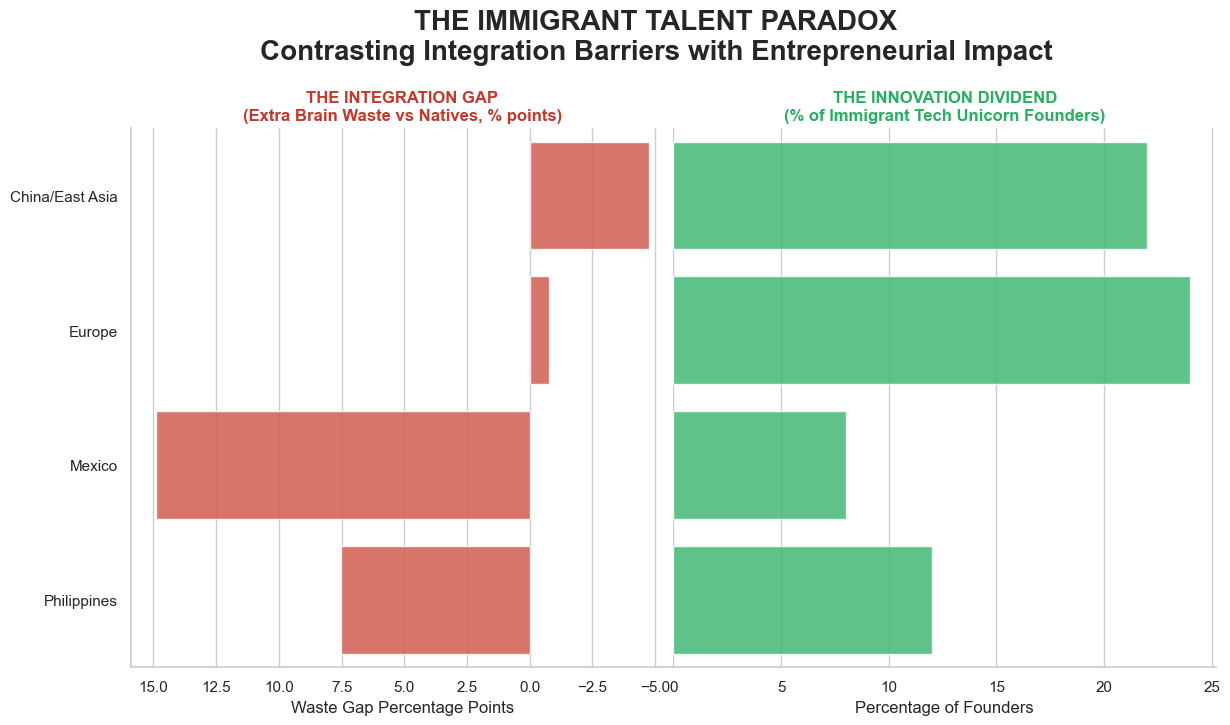

In [22]:
# Define Brain Waste (Educational mismatch)
# OCC >= 3600 is a standard proxy for low-skill/service roles in ACS
educated_only['is_brain_waste'] = (educated_only['OCC'] >= 3600).astype(int)
# Aggregate national stats to find Brain Waste Percentage by Region
region_stats = educated_only.groupby('Origin_Region').apply(
    lambda x: (x['is_brain_waste'] * x['PERWT']).sum() / x['PERWT'].sum() * 100
).reset_index(name='brain_waste_pct')
# Calculate Integration Gap (Difference from Native-born baseline)
native_waste = region_stats.loc[region_stats['Origin_Region'] == 'Native-born (USA)', 'brain_waste_pct'].values[0]
region_stats['integration_gap'] = region_stats['brain_waste_pct'] - native_waste
# Remove Native-born and 'Other' from the final visual so we just focus on Immigrant regions
viz_df = region_stats[~region_stats['Origin_Region'].isin(['Native-born (USA)', 'Other'])]

def plot_paradox_mirror_chart(viz_df):
    """
    Creates a Dual-Panel Mirror Chart comparing the Brain Waste Integration Gap
    (Left) with the Innovation Dividend (Right).
    """
    # Setup Data for Dividend (These represent the % of US Unicorn founders by origin)
    dividend_data = {
        'Region': ['Europe', 'Mexico', 'India', 'China/East Asia', 'Philippines'],
        'Unicorn_Founders_Pct': [24, 8, 38, 22, 12] 
    }
    dividend_df = pd.DataFrame(dividend_data)
    
    # Merge Integration Gap data with Innovation Dividend data
    merged = pd.merge(viz_df, dividend_df, left_on='Origin_Region', right_on='Region')
    # Create the Mirror Chart layout
    sns.set_theme(style="whitegrid", palette="muted")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
    plt.subplots_adjust(wspace=0) # Mirror effect
    # --- LEFT PANEL: The Integration Gap (Brain Waste) ---
    sns.barplot(x='integration_gap', y='Origin_Region', data=merged, 
                ax=ax1, color='#e74c3c', alpha=0.85)
    ax1.set_title('THE INTEGRATION GAP\n(Extra Brain Waste vs Natives, % points)', fontweight='bold', color='#c0392b')
    ax1.invert_xaxis()  # Mirroring
    ax1.set_xlabel('Waste Gap Percentage Points')
    ax1.set_ylabel('')
    # --- RIGHT PANEL: The Innovation Dividend (Unicorn Founders) ---
    sns.barplot(x='Unicorn_Founders_Pct', y='Origin_Region', data=merged, 
                ax=ax2, color='#2ecc71', alpha=0.85)
    ax2.set_title('THE INNOVATION DIVIDEND\n(% of Immigrant Tech Unicorn Founders)', fontweight='bold', color='#27ae60')
    ax2.set_xlabel('Percentage of Founders')
    ax2.set_ylabel('')
    ax2.tick_params(left=False) # Remove inner labels for mirror look
    # Overall Style tweaks
    plt.suptitle('THE IMMIGRANT TALENT PARADOX\nContrasting Integration Barriers with Entrepreneurial Impact', 
                 fontsize=20, fontweight='heavy', y=1.05)
    
    for ax in [ax1, ax2]:
        sns.despine(ax=ax, left=True if ax == ax2 else False)
    return fig
# 5. EXECUTE AND SHOW PLOT
fig = plot_paradox_mirror_chart(viz_df)
plt.show()